In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
np.random.seed(42)
n = 200
x = np.linspace(-3 , 3 , n)
X = x.reshape(-1 , 1)
y1_true = 0.5 * x ** 3 - x
y2_true = -0.3 * x ** 3 + 0.5 * x
y1 = y1_true + np.random.normal(0 , 1.0 , n)
y2 = y2_true + np.random.normal(0 , 1.0 , n)
Y = np.column_stack([y1 , y2])
model = LinearRegression()
model.fit(X , Y)
Y_pred = model.predict(X)
mse_y1 = mean_squared_error(y1 , Y_pred[ : , 0])
mse_y2 = mean_squared_error(y2 , Y_pred[ : , 1])
avg_mse = (mse_y1 + mse_y2) / 2

LinearRegression()

Text(0.5, 0.98, 'One Model, Two Targets: Multi-Output Regression')

Text(0.5, 1.0, 'Target 1')

Text(0.5, 0, 'X')

Text(0, 0.5, 'y')

Text(0.03, 0.97, 'MSE ≈ 4.824')

Text(0.5, 1.0, 'Target 2')

Text(0.5, 0, 'X')

Text(0.03, 0.97, 'MSE ≈ 2.692')

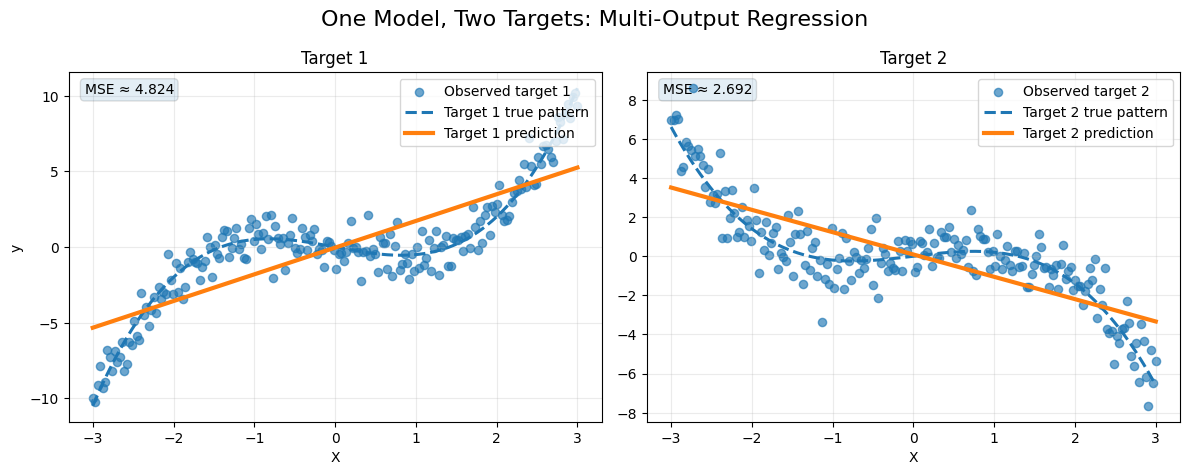

In [3]:
fig , axes = plt.subplots(1 , 2 , figsize = (12 , 4.8) , sharex = True)
fig.suptitle("One Model, Two Targets: Multi-Output Regression" , fontsize = 16)

axes[0].scatter(x , y1 , alpha = 0.65 , s = 35 , label = "Observed target 1")
axes[0].plot(x , y1_true , linestyle = "--" , linewidth = 2.2 , label = "Target 1 true pattern")
axes[0].plot(x , Y_pred[ : , 0] , linewidth = 3 , label = "Target 1 prediction")
axes[0].set_title("Target 1")
axes[0].set_xlabel("X")
axes[0].set_ylabel("y")
axes[0].grid(alpha = 0.25)
axes[0].legend(loc = "upper right")
axes[0].text(
    0.03 , 0.97 , f"MSE ≈ {mse_y1:.3f}" , transform = axes[0].transAxes ,
    va = "top" , bbox = dict(boxstyle = "round , pad = 0.3" , alpha = 0.12)
)

axes[1].scatter(x , y2 , alpha = 0.65 , s = 35 , label = "Observed target 2")
axes[1].plot(x , y2_true , linestyle = "--" , linewidth = 2.2 , label = "Target 2 true pattern")
axes[1].plot(x , Y_pred[ : , 1] , linewidth = 3 , label = "Target 2 prediction")
axes[1].set_title("Target 2")
axes[1].set_xlabel("X")
axes[1].grid(alpha = 0.25)
axes[1].legend(loc = "upper right")
axes[1].text(
    0.03 , 0.97 , f"MSE ≈ {mse_y2:.3f}" , transform = axes[1].transAxes ,
    va = "top" , bbox = dict(boxstyle = "round , pad = 0.3" , alpha = 0.12)
)

plt.tight_layout()
plt.show()

<Figure size 700x480 with 0 Axes>

Text(0.5, 1.0, 'Evaluate Each Target Separately')

Text(0, 0.5, 'MSE')

Text(0.0, 4.873597448186808, '4.82')

Text(1.0, 2.7416070776595034, '2.69')

Text(0.98, 0.95, 'Average MSE ≈ 3.758')

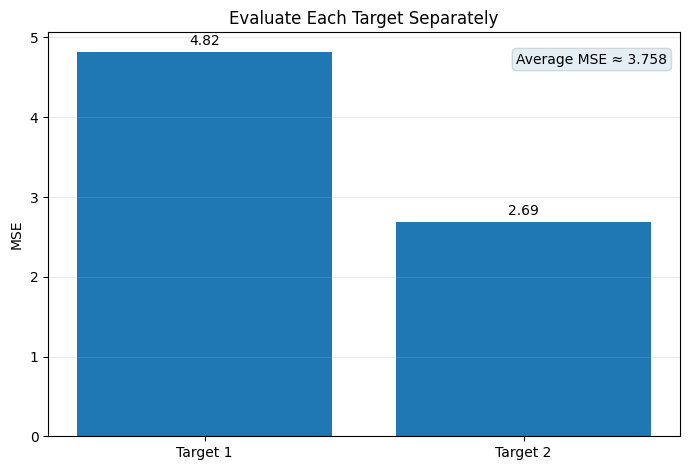

In [4]:
plt.figure(figsize = (7 , 4.8))
bars = plt.bar(["Target 1" , "Target 2"] , [mse_y1 , mse_y2])
plt.title("Evaluate Each Target Separately")
plt.ylabel("MSE")
plt.grid(axis = "y" , alpha = 0.25)
for bar , val in zip(bars , [mse_y1 , mse_y2]):
    plt.text(bar.get_x() + bar.get_width() / 2 , bar.get_height() + 0.05 ,
             f"{val:.2f}" , ha = "center" , va = "bottom")
plt.text(
    0.98 , 0.95 , f"Average MSE ≈ {avg_mse:.3f}" ,
    transform = plt.gca().transAxes , ha = "right" ,
    va = "top" , bbox = dict(boxstyle = "round , pad = 0.3" , alpha = 0.12)
)
plt.tight_layout()
plt.show()